# Genetik Varyant Patojenisite Tahmini
## TEKNOFEST Sağlıkta Yapay Zeka

Bu notebook, genetik varyantların patojenik (hastalığa neden olan) veya benign (zararsız) olup olmadığını tahmin eden bir makine öğrenmesi modeli geliştirme sürecini adım adım göstermektedir.

In [18]:
import sys
sys.path.append('../src')
from imports import *
from preprocessing import preprocess_data

## 1. Veri Yükleme ve Keşif

In [19]:
data = pd.read_csv(os.path.join(PROJECT_DIR, "data", "demo_final_dataset.csv"))
print(f"Veri boyutu: {data.shape}")
data.head()

Veri boyutu: (3021, 18)


,unique_id,label,sift_score,polyphen_score,cadd_phred,cadd_raw,revel,gnomad_af,gnomadg_af,alphamissense_score,alphamissense_class,amino_acids,codons,consequence,GeneSymbol,panel,sift_pred,polyphen_pred
0,1_9710459_C_A,0,deleterious(0),possibly_damaging(0.626),23.5,3.796959,0.166,9.373e-05,2.627e-05,0.1775,likely_benign,P/T,Ccc/Acc,missense_variant,PIK3CD,genel,NaN,NaN
1,1_9710567_C_T,0,tolerated(0.22),benign(0.031),21.5,3.140993,0.238,1.573e-05,9.214e-05,0.0757,likely_benign,R/C,Cgc/Tgc,missense_variant,PIK3CD,genel,NaN,NaN
2,1_9715849_G_A,1,deleterious(0),probably_damaging(0.985),29.6,5.268086,0.244,-,-,0.5383,ambiguous,G/D,gGc/gAc,"missense_variant,splice_region_variant",PIK3CD,genel,NaN,NaN
3,1_9715914_T_A,0,tolerated(0.32),benign(0.15),20.2,2.772749,0.165,0.0009032,0.001129,0.1385,likely_benign,F/I,Ttc/Atc,missense_variant,PIK3CD,genel,NaN,NaN
4,1_9715927_C_T,0,tolerated(0.06),benign(0.007),19.56,2.629122,0.102,4.043e-05,0.0004004,0.077,likely_benign,A/V,gCg/gTg,missense_variant,PIK3CD,genel,NaN,NaN


Sınıf Dağılımı:
label
0    1520
1    1501
Name: count, dtype: int64


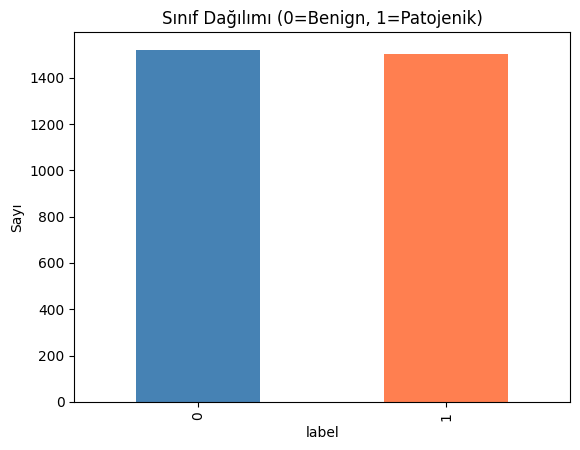

In [20]:
# Sınıf dağılımı
print("Sınıf Dağılımı:")
print(data['label'].value_counts())
data['label'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Sınıf Dağılımı (0=Benign, 1=Patojenik)')
plt.ylabel('Sayı')
plt.show()

Panel Dağılımı:
panel
genel               2229
herediter_kanser     400
pah                  252
cftr                 140
Name: count, dtype: int64


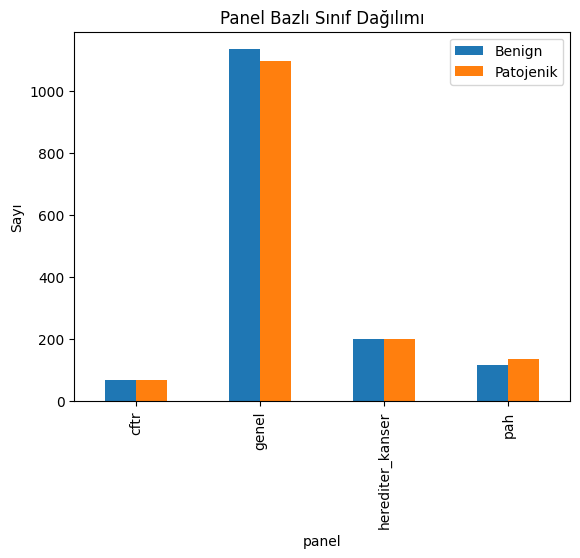

In [21]:
# Panel dağılımı
print("Panel Dağılımı:")
print(data['panel'].value_counts())
data.groupby(['panel', 'label']).size().unstack().plot(kind='bar')
plt.title('Panel Bazlı Sınıf Dağılımı')
plt.ylabel('Sayı')
plt.legend(['Benign', 'Patojenik'])
plt.show()

In [22]:
# Eksik değer analizi
missing = data.isin(['-']).sum() + data.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Eksik Değerler:")
print(missing)

Eksik Değerler:
polyphen_pred          2723
sift_pred              2710
gnomadg_af             1627
gnomad_af              1247
alphamissense_class    1187
alphamissense_score    1187
revel                   662
cadd_phred              541
cadd_raw                541
polyphen_score          536
sift_score              302
codons                   80
amino_acids              80
dtype: int64


## 2. Ön İşleme
- SIFT ve PolyPhen skorları string'den sayıya çevrildi
- `-` değerleri NaN'a dönüştürüldü
- Eksik sayısal değerler median ile dolduruldu
- Kategorik değişkenler one-hot encode edildi

In [23]:
X, y, panel = preprocess_data(data)
print(f"Feature sayısı: {X.shape[1]}")
print(f"Örnek sayısı: {X.shape[0]}")
print(f"\nFeature'lar: {list(X.columns)}")

Feature sayısı: 57
Örnek sayısı: 3021

Feature'lar: ['sift_score', 'polyphen_score', 'cadd_phred', 'cadd_raw', 'revel', 'gnomad_af', 'gnomadg_af', 'alphamissense_score', 'alphamissense_class_likely_benign', 'alphamissense_class_likely_pathogenic', 'consequence_intron_variant', 'consequence_missense_variant', 'consequence_missense_variant,NMD_transcript_variant', 'consequence_missense_variant,splice_region_variant', 'consequence_missense_variant,splice_region_variant,NMD_transcript_variant', 'consequence_stop_gained', 'consequence_stop_gained,splice_region_variant', 'consequence_upstream_gene_variant', 'ref_amino_C', 'ref_amino_D', 'ref_amino_E', 'ref_amino_F', 'ref_amino_G', 'ref_amino_H', 'ref_amino_I', 'ref_amino_K', 'ref_amino_L', 'ref_amino_M', 'ref_amino_N', 'ref_amino_P', 'ref_amino_Q', 'ref_amino_R', 'ref_amino_S', 'ref_amino_T', 'ref_amino_V', 'ref_amino_W', 'ref_amino_Y', 'alt_amino_A', 'alt_amino_C', 'alt_amino_D', 'alt_amino_E', 'alt_amino_F', 'alt_amino_G', 'alt_amino_H', '

## 3. Train/Test Split
%80 eğitim, %20 test. Stratified split ile sınıf oranı korundu.

In [24]:
X_train, X_test, y_train, y_test, panel_train, panel_test = train_test_split(
    X, y, panel, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} örnek")
print(f"Test:  {X_test.shape[0]} örnek")

Train: 2416 örnek
Test:  605 örnek


## 4. Baseline Modeller
Logistic Regression ve Random Forest ile referans noktası oluşturuldu.

In [25]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.85      0.82      0.84       304
           1       0.83      0.86      0.84       301

    accuracy                           0.84       605
   macro avg       0.84      0.84      0.84       605
weighted avg       0.84      0.84      0.84       605

AUC-ROC: 0.9204


In [26]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))
print(f"AUC-ROC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       304
           1       0.89      0.89      0.89       301

    accuracy                           0.89       605
   macro avg       0.89      0.89      0.89       605
weighted avg       0.89      0.89      0.89       605

AUC-ROC: 0.9537


## 5. XGBoost Model
Sınıf dengesizliği için `scale_pos_weight`, overfitting için `early_stopping` kullanıldı.

In [27]:
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_weight, eval_metric='logloss',
    random_state=42, early_stopping_rounds=20
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb = xgb_model.predict(X_test)
print("XGBOOST")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]):.4f}")

XGBOOST
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       304
           1       0.92      0.87      0.90       301

    accuracy                           0.90       605
   macro avg       0.90      0.90      0.90       605
weighted avg       0.90      0.90      0.90       605

AUC-ROC: 0.9626


## 6. Model Karşılaştırması

In [28]:
from sklearn.metrics import f1_score as f1

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'F1 (macro)': [
        round(f1(y_test, y_pred_lr, average='macro'), 4),
        round(f1(y_test, y_pred_rf, average='macro'), 4),
        round(f1(y_test, y_pred_xgb, average='macro'), 4)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]), 4),
        round(roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]), 4),
        round(roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]), 4)
    ]
})
comparison.set_index('Model')

,F1 (macro),AUC-ROC
Model,,
Logistic Regression,0.8396,0.9204
Random Forest,0.8909,0.9537
XGBoost,0.8991,0.9626


## 7. Panel Bazlı Değerlendirme (XGBoost)

In [29]:
for p in panel_test.unique():
    idx = panel_test == p
    y_pred_p = xgb_model.predict(X_test[idx])
    y_proba_p = xgb_model.predict_proba(X_test[idx])[:,1]
    print(f"\n{'='*40}")
    print(f"Panel: {p} ({idx.sum()} örnek)")
    print(f"{'='*40}")
    print(classification_report(y_test[idx], y_pred_p))
    print(f"AUC-ROC: {roc_auc_score(y_test[idx], y_proba_p):.4f}")


Panel: genel (430 örnek)
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       214
           1       0.94      0.93      0.94       216

    accuracy                           0.94       430
   macro avg       0.94      0.94      0.94       430
weighted avg       0.94      0.94      0.94       430

AUC-ROC: 0.9813

Panel: pah (46 örnek)
              precision    recall  f1-score   support

           0       0.93      0.61      0.74        23
           1       0.71      0.96      0.81        23

    accuracy                           0.78        46
   macro avg       0.82      0.78      0.78        46
weighted avg       0.82      0.78      0.78        46

AUC-ROC: 0.9357

Panel: herediter_kanser (96 örnek)
              precision    recall  f1-score   support

           0       0.76      0.96      0.85        52
           1       0.93      0.64      0.76        44

    accuracy                           0.81        96
   macro av

## 8. SHAP Açıklanabilirlik
Modelin kararlarını etkileyen en önemli özellikler:

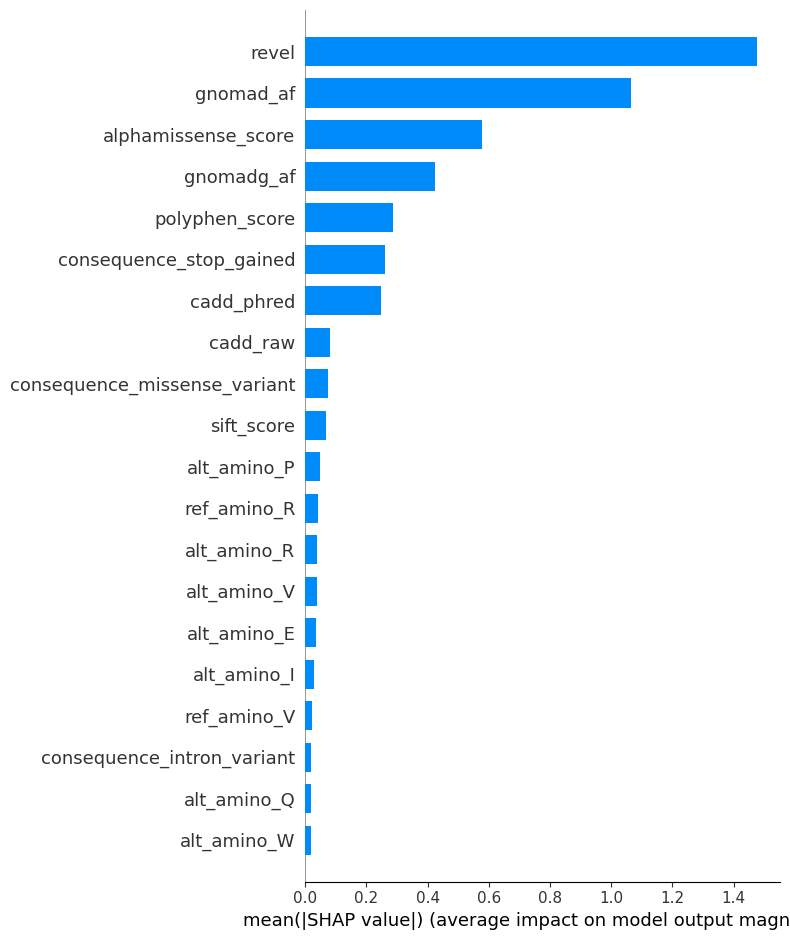

In [30]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

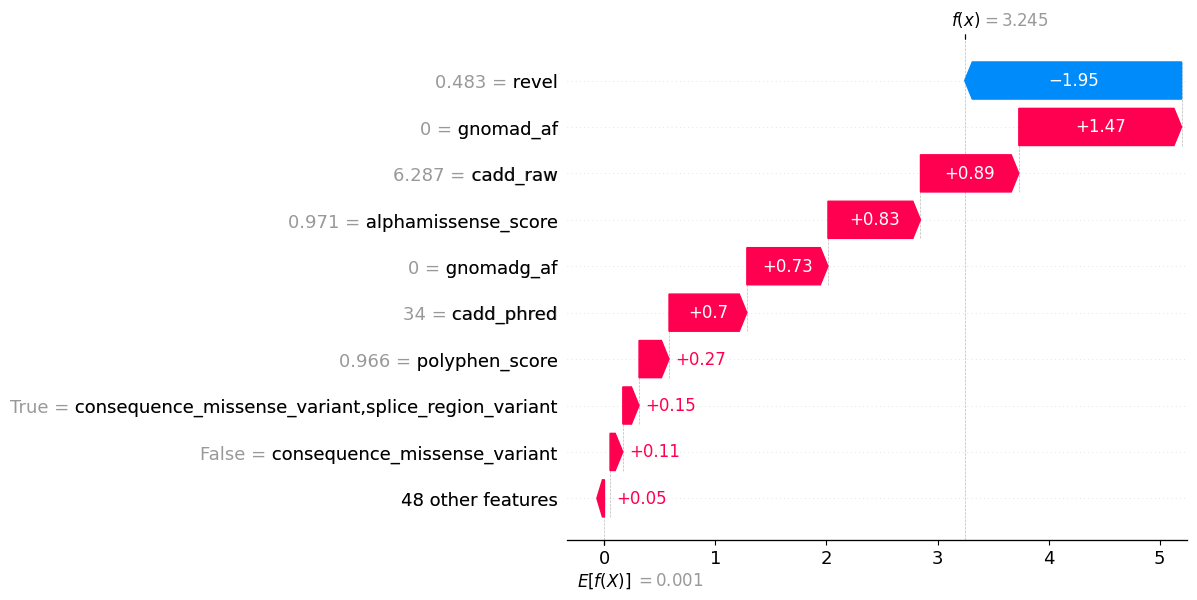

In [31]:
# Lokal açıklama — tek bir varyant neden patojenik tahmin edildi?
shap.waterfall_plot(explainer(X_test)[0])

## 9. Eşik Optimizasyonu
Klinik bağlamda yanlış negatif (hasta varyantın atlanması) daha risklidir. Bu nedenle varsayılan 0.5 eşiği yerine yüksek recall sağlayan bir eşik seçildi.

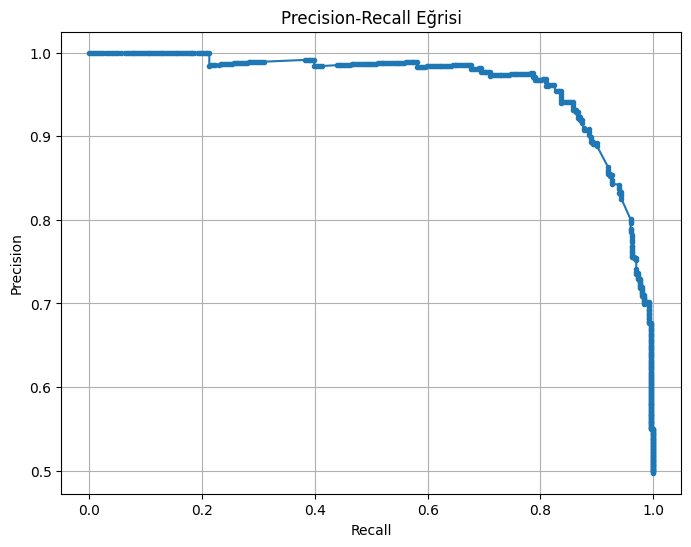

In [32]:
y_proba = xgb_model.predict_proba(X_test)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Eğrisi')
plt.grid()
plt.show()

In [33]:
# Optimal eşik: recall >= 0.90
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
mask = recall[:-1] >= 0.90

if mask.any():
    best_idx = np.argmax(f1_scores[:-1][mask])
    best_threshold = thresholds[mask][best_idx]
else:
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]

y_pred_opt = (y_proba >= best_threshold).astype(int)
print(f"Seçilen eşik: {best_threshold:.4f}")
print(f"Recall: {(y_pred_opt[y_test==1].sum()/(y_test==1).sum()):.4f}")
print(classification_report(y_test, y_pred_opt))

Seçilen eşik: 0.4114
Recall: 0.9003
              precision    recall  f1-score   support

           0       0.90      0.89      0.90       304
           1       0.89      0.90      0.90       301

    accuracy                           0.90       605
   macro avg       0.90      0.90      0.90       605
weighted avg       0.90      0.90      0.90       605



## 10. Cross-Validation
5-fold stratified cross-validation ile modelin farklı veri bölmelerindeki tutarlılığı doğrulandı.

In [34]:
cv_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_weight, eval_metric='logloss',
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_cv = cross_val_score(cv_model, X, y, cv=cv, scoring='f1')
auc_cv = cross_val_score(cv_model, X, y, cv=cv, scoring='roc_auc')
print(f"F1  — Ortalama: {f1_cv.mean():.4f} ± {f1_cv.std():.4f}")
print(f"AUC — Ortalama: {auc_cv.mean():.4f} ± {auc_cv.std():.4f}")

F1  — Ortalama: 0.8977 ± 0.0097
AUC — Ortalama: 0.9683 ± 0.0035


## Sonuç
- XGBoost modeli F1: 0.90, AUC: 0.96 ile en iyi performansı gösterdi
- 5-fold CV ile tutarlılık doğrulandı (F1: 0.8988 ± 0.01)
- SHAP analizi ile model kararları açıklanabilir hale getirildi
- Klinik bağlama uygun eşik (0.41) ile recall 0.90'a yükseltildi
- Panel bazlı en güçlü performans genel panelde (F1: 0.94), en zorlu panel herediter kanser (F1: 0.76)